# Fire impacts simulations

This notebook demonstrates the fire impacts simulation modules.

It is assumed that you have a `FireImpactsProject` populated with all pre-processed data for the catchment.

In [1]:
import logging
logging.basicConfig(level=logging.INFO,format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

from fire_impacts.sim import aggregate_rainfall_data, lumped_daily_rusle, gridded_total_rusle, debris_flow
from fire_impacts import FireImpactsProject

import matplotlib.pyplot as plt


2025-02-23 14:21:16,580 - numexpr.utils - INFO - NumExpr defaulting to 16 threads.


## Load project

In [2]:
proj = FireImpactsProject('/home/joelrahman/Geospatial/waterra-bushfire/example-project/',exist_ok=True)

In [3]:
proj.catchments

['DR_Primary_Catchment_Thomson', 'Upper_Yarra']

## Rainfall data

Both the erosion (RUSLE) and debris flow modules rely on subdaily rainfall data. The erosion modules, demonstrated here, relies on 30 minute data, while the debris flow relies on 12 minute data.

Furthermore, it is encouraged that both modules be run stochastically, using multiple rainfall replicates.

The library provides functionality for processing stochastic rainfall data, generated by [pyraingen](https://github.com/crdykman/pyraingen).

We will initially run a short simulation of only three days.

In [4]:
rain_data_start = '2015-01-01'
rain_data_end = '2015-01-03'

# Pointer to pyraingen generated stochastic rainfall
rainfall_data = '/home/joelrahman/Geospatial/waterra-bushfire/rusle/subdaily_012345.nc'


In [5]:
aggregate_rainfall_data?

Signature:
aggregate_rainfall_data(
    netcdf_path,
    rain_data_start,
    rain_data_end,
    time_res='30min',
)
Docstring:
Aggregates subdaily stochastic rainfall data from a netCDF file to a specified time resolution.

Input data is expected to be from pyraingen, with data stored by simulation x day x subday.

Returned dataframe is simulation (columns) x time (rows), with rainfall values aggregated to the specified time resolution.

Parameters:
- netcdf_path (str): Path to the netCDF file containing rainfall data.
- rain_data_start (datetime): Start date for the rainfall data.
- rain_data_end (datetime): End date for the rainfall data.
- time_res (str): Time resolution for the aggregated data. Default is '30min'.

Returns:
- r_agg (DataFrame): DataFrame with aggregated rainfall by simulation.
File:      ~/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/sim/rainfall.py
Type:      function

In [6]:
rainfall_30min = aggregate_rainfall_data(rainfall_data,rain_data_start,rain_data_end)

In [7]:
rainfall_30min

simulation,0,1,2,3,4,5,6,7,8,9
time,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,2.4
2015-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,12.3
2015-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2015-01-01 01:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2015-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...
2015-01-03 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00625,0.0
2015-01-03 22:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00625,0.0
2015-01-03 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00625,0.0


**Note:** The pyraingen data includes 10 stochastic replicates. In the following examples, we will only use one replicate.


## Erosion - Daily simulation

Erosion processed are modelled cell-by-cell, timestep-by-timestep.

This can result in a large amount of output that in most cases is not directly usable.

The library currently provides two alternative function calls, depending on the nature of outputs required:

* `lumped_daily_rusle`: For modelling erosion processes and receiving daily outputs lumped to the subcatchment scale, and
* `gridded_total_rusle`: For modelling erosion processes and receiving gridded outputs summing the erosion over the simulation period.

Both of these functions rely on a low level function which can be used to provide customise outputs


First, lets run the lumped daily function:

In [8]:
lumped_daily_rusle?

Signature:
lumped_daily_rusle(
    project: fire_impacts.pre.project.FireImpactsProject,
    rainfall,
    catchment=None,
)
Docstring:
Calculates RUSLE and SDR erosion values for sub-catchments based on 30min rainfall sequence.

Parameters:
- project (fire_impacts.FireImpactsProject): Current project
- rainfall (Series-like): 30 minute rainfall data
- catchment (str): Name of the catchment to process. If None, process all catchments.

Returns:
- RUSLE_df (DataFrame): DataFrame summarizing RUSLE and sediment delivery results.
File:      ~/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/sim/rusle.py
Type:      function

In [9]:
lumped_daily_rusle(proj,rainfall_30min[9],'DR_Primary_Catchment_Thomson')

2025-02-23 14:21:22,297 - fire_impacts.pre.util - INFO - Reading raster /home/joelrahman/Geospatial/waterra-bushfire/example-project/Catchments/DR_Primary_Catchment_Thomson/FireSeverity/dNBR.tif and reprojecting to EPSG:28355
2025-02-23 14:21:22,347 - fire_impacts.sim.rusle - INFO - Processing subcatchment 1
2025-02-23 14:21:22,615 - fire_impacts.util - INFO - Loading data from /home/joelrahman/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/../data/ash_constituents.csv
2025-02-23 14:21:22,624 - fire_impacts.sim.rusle - INFO - Done
2025-02-23 14:21:22,630 - fire_impacts.sim.rusle - INFO - Done


,Sub-catchment,Day,Rainfall (total daily),Max Rain Intensity (30 mins),Max Erosivity (30 mins),RUSLE,RUSLE_SDR,RUSLE (Low severity),RUSLE (High severity),RUSLE_SDR (Low severity),RUSLE_SDR (High severity),Carbon (Tonne),Phosphorous (Tonne),Nitrogent (Tonne),Calcium (Tonne),Magnesium (Tonne),Potassium (Tonne),Silicon (Tonne)
0,Sub_1,2015-01-01,14.7,24.6,79.3,9636.599609,894.900024,9636.599609,0.0,894.900024,0.0,221.300003,0.1,3.5,3.2,0.8,1.0,1.9
1,Sub_1,2015-01-02,23.5,17.1,35.0,7519.600098,698.299988,7519.600098,0.0,698.299988,0.0,172.699997,0.1,2.7,2.5,0.6,0.7,1.5
2,Sub_1,2015-01-03,2.6,2.9,0.5,86.800003,8.100000,86.800003,0.0,8.100000,0.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,Sub_1,2015-01-04,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


## Erosion - Gridded simulation

This time, we will run for a longer time period (2 years) and retrieve a single map of predicted erosion over this time period

In [10]:
rain_data_start = '2015-01-01'
rain_data_end = '2016-12-31'
rainfall_30min = aggregate_rainfall_data(rainfall_data,rain_data_start,rain_data_end)

In [11]:
gridded_total_rusle?

Signature:
gridded_total_rusle(
    project: fire_impacts.pre.project.FireImpactsProject,
    rainfall,
    catchment=None,
)
Docstring: <no docstring>
File:      ~/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/sim/rusle.py
Type:      function

In [12]:
%time eroded, delivered, transform = gridded_total_rusle(proj,rainfall_30min[9],'DR_Primary_Catchment_Thomson')

2025-02-23 14:21:24,412 - fire_impacts.pre.util - INFO - Reading raster /home/joelrahman/Geospatial/waterra-bushfire/example-project/Catchments/DR_Primary_Catchment_Thomson/FireSeverity/dNBR.tif and reprojecting to EPSG:28355
2025-02-23 14:21:59,818 - fire_impacts.sim.rusle - INFO - Done


CPU times: user 35.1 s, sys: 55.5 ms, total: 35.1 s
Wall time: 35.7 s


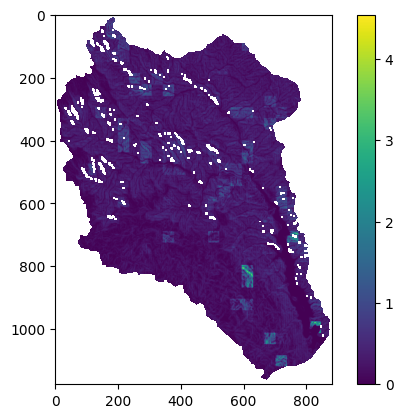

In [13]:
plt.imshow(eroded)
plt.colorbar()

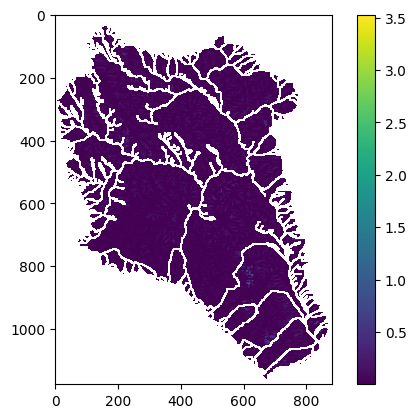

In [14]:
plt.imshow(delivered)
plt.colorbar()

## Debris Flow

Debris flow operates on headwaters only and uses 12 minute rainfall data.


In [15]:
rain_data_start = '2015-01-01'
rain_data_end = '2016-12-31'
rainfall = aggregate_rainfall_data(rainfall_data,rain_data_start,rain_data_end,time_res='12min')
rainfall

simulation,0,1,2,3,4,5,6,7,8,9
time,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4
2015-01-01 00:12:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-01 00:24:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.6
2015-01-01 00:36:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.9
2015-01-01 00:48:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.8
...,...,...,...,...,...,...,...,...,...,...
2016-12-31 23:12:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-12-31 23:24:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-12-31 23:36:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
results = debris_flow(proj,rainfall[9])

2025-02-23 14:23:30,948 - fire_impacts.pre.project - INFO - Processing 2 catchments
2025-02-23 14:23:32,755 - fire_impacts.pre.util - INFO - Reading raster /home/joelrahman/Geospatial/waterra-bushfire/example-project/Catchments/DR_Primary_Catchment_Thomson/Soils/CLAY/CLY_000_005_EV_N_P_AU_NAT_C.tif and reprojecting to EPSG:28355
2025-02-23 14:23:32,800 - fire_impacts.pre.util - INFO - Reading raster /home/joelrahman/Geospatial/waterra-bushfire/example-project/Catchments/DR_Primary_Catchment_Thomson/Soils/CLAY/CLY_005_015_EV_N_P_AU_NAT_C.tif and reprojecting to EPSG:28355
2025-02-23 14:23:32,843 - fire_impacts.util - INFO - Loading data from /home/joelrahman/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/../data/HFlookup_b30pt27.csv
2025-02-23 14:23:33,126 - fire_impacts.util - INFO - Loading data from /home/joelrahman/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/../data/debris-constituents.csv
2025-02-23 14:23:36,635 - fire_impacts.sim.debris - INFO - Done!
2025-02-23 14:23

In [18]:
results['DR_Primary_Catchment_Thomson']

,ID,Slope_mean,Slope_max,Slope_min,Slope_median,Slope_std,dNBR_mean,dNBR_max,dNBR_min,dNBR_median,...,Silicon (Kg),Aridity_mean_adjusted,dNBR_mean_adjusted,Slope_mean_adjusted,TSF_Year_1,I12_crit_mean_Year_1,TSF_Year_2,I12_crit_mean_Year_2,Year1_num_events,Year2_num_events
0,1,44.464482,90.000000,12.473379,23.270140,34.376008,0.019828,0.305048,-0.118995,0.006805,...,37.850806,0.75,0,0.4,0.434,500.0,1.434,500.0,0,0
1,2,39.355039,90.000000,7.946159,18.287861,34.872538,-0.020921,0.144932,-0.216518,-0.025949,...,0.000000,1.00,0,0.4,0.434,298.9,1.434,500.0,0,0
2,3,30.211060,90.000000,10.092636,23.808142,22.026850,-0.047369,0.137227,-0.176485,-0.050165,...,37.850806,0.75,0,0.3,0.434,500.0,1.434,500.0,0,0
3,4,36.300675,90.000000,17.587698,23.320000,26.930483,-0.033537,0.287092,-0.129751,-0.067595,...,44.741202,0.75,0,0.4,0.434,500.0,1.434,500.0,0,0
4,5,28.762536,90.000000,15.644652,20.978115,21.453434,-0.095036,-0.012033,-0.162078,-0.098585,...,44.741202,1.00,-100,0.3,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6547,6548,10.697701,17.699951,1.508949,10.611847,4.665863,-0.050852,-0.005517,-0.084704,-0.053574,...,0.000000,1.25,-100,0.1,NaN,NaN,NaN,NaN,0,0
6548,6549,6.336387,12.978604,1.655630,6.794971,2.963053,-0.039242,0.041094,-0.118439,-0.037847,...,11.486702,1.25,0,0.1,0.434,309.0,1.434,500.0,0,0
6549,6550,14.607425,20.739847,7.229435,14.340466,3.752962,-0.044715,-0.004697,-0.098168,-0.042786,...,184.486925,1.25,0,0.1,0.434,309.0,1.434,500.0,0,0
6550,6551,26.608857,90.000000,4.593777,13.296504,31.899681,-0.048116,-0.015705,-0.081969,-0.047823,...,184.486925,1.25,0,0.3,0.434,188.9,1.434,500.0,0,0
